# Backprojection and Tomographic Reconstruction

Computed tomography reconstructs an unknown image from line integrals at multiple angles.
The forward operator is the Radon transform:
$$
\mathcal R f(\theta,s)=\int_{\langle x,\omega_\theta\rangle=s} f(x)\,d\ell.
$$
Inversion is ill-conditioned and requires filtering; filtered backprojection remains a cornerstone method.

We implement a simple pedagogical pipeline: forward projections, sinogram visualization, and progressive reconstruction.


## Environment

We implement a lightweight discrete Radon transform using rotated image sums.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from ipywidgets import interact, IntSlider

plt.rcParams["figure.dpi"] = 120


## Phantom construction

Use a compact synthetic object with contrast changes.


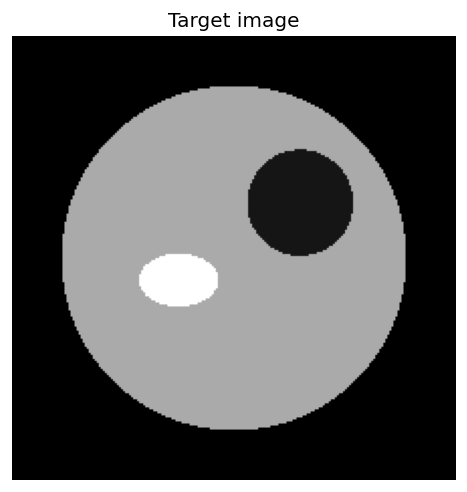

In [2]:
n = 220
y, x = np.mgrid[-1:1:complex(0, n), -1:1:complex(0, n)]
phantom = np.zeros((n, n))
phantom += 0.8 * ((x**2 + y**2) < 0.78**2)
phantom -= 0.7 * (((x - 0.30) ** 2 + (y - 0.25) ** 2) < 0.24**2)
phantom += 0.4 * (((x + 0.25) ** 2 / 0.18**2 + (y + 0.1) ** 2 / 0.12**2) < 1.0)
phantom = (phantom - phantom.min()) / (phantom.max() - phantom.min())

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.imshow(phantom, cmap="gray", origin="lower")
ax.set_title("Target image")
ax.axis("off")
plt.show()


## Discrete Radon transform

For each angle, rotate image then integrate along one axis.


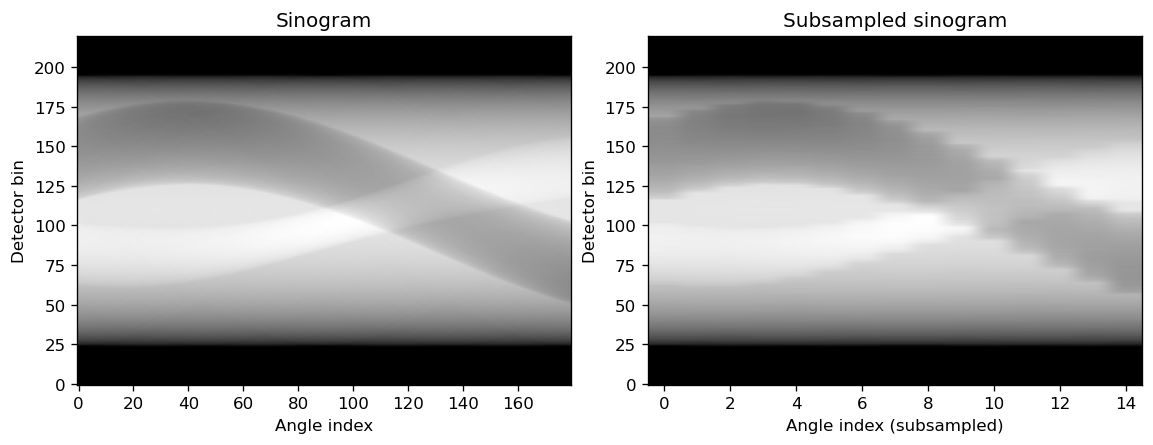

In [3]:
def radon_discrete(img, angles_deg):
    sinogram = []
    for a in angles_deg:
        rot = rotate(img, angle=a, reshape=False, order=1, mode="constant", cval=0.0)
        sinogram.append(rot.sum(axis=0))
    return np.stack(sinogram, axis=1)

angles = np.linspace(0, 180, 180, endpoint=False)
sino = radon_discrete(phantom, angles)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), constrained_layout=True)
axes[0].imshow(sino, cmap="gray", aspect="auto", origin="lower")
axes[0].set_title("Sinogram")
axes[0].set_xlabel("Angle index")
axes[0].set_ylabel("Detector bin")
axes[1].imshow(sino[:, ::12], cmap="gray", aspect="auto", origin="lower")
axes[1].set_title("Subsampled sinogram")
axes[1].set_xlabel("Angle index (subsampled)")
axes[1].set_ylabel("Detector bin")
plt.show()


## Filtered backprojection

In frequency, each projection is multiplied by a ramp-like filter $|\omega|$ before backprojection.
We use a Hann-windowed ramp for stability.


In [4]:
def ramp_filter(n, window=True):
    freqs = np.fft.rfftfreq(n)
    filt = freqs.copy()
    if window:
        filt *= (0.5 + 0.5 * np.cos(np.pi * freqs))
    return filt

def filtered_backprojection(sinogram, angles_deg):
    m, p = sinogram.shape
    filt = ramp_filter(m, window=True)
    projf = np.fft.rfft(sinogram, axis=0)
    projf *= filt[:, None]
    proj = np.fft.irfft(projf, n=m, axis=0)
    rec = np.zeros((m, m), dtype=float)
    for j, a in enumerate(angles_deg):
        back = np.tile(proj[:, j], (m, 1))
        rec += rotate(back, angle=-a, reshape=False, order=1, mode="constant", cval=0.0)
    rec *= np.pi / (2 * len(angles_deg))
    rec -= rec.min()
    rec /= rec.max() + 1e-12
    return rec


## Reconstruction quality vs number of views

Fewer angles create streak artifacts; more views improve fidelity.


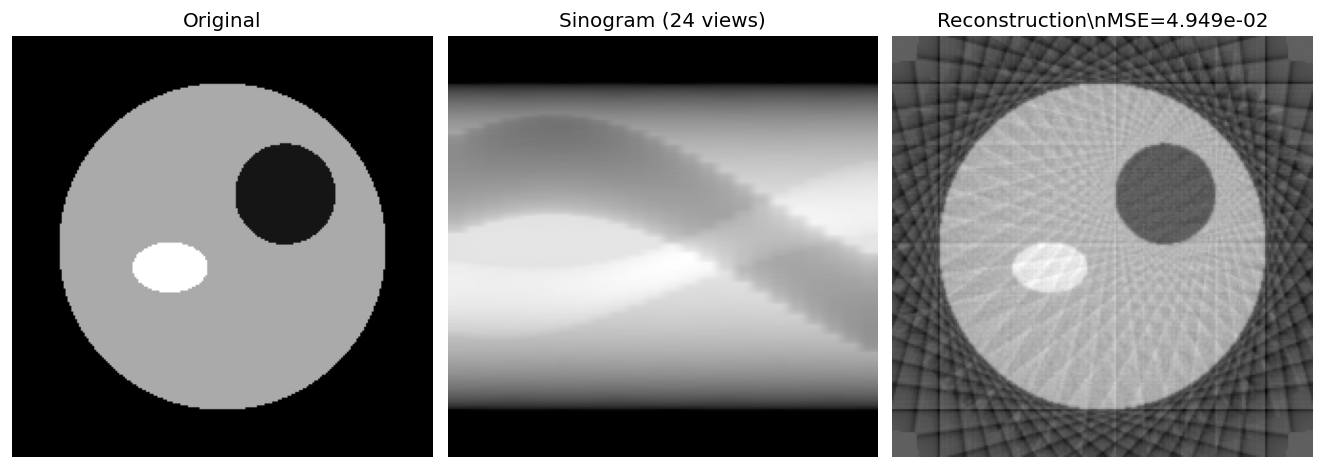

In [5]:
def show_reconstruction(p=24):
    ang = np.linspace(0, 180, p, endpoint=False)
    sino = radon_discrete(phantom, ang)
    rec = filtered_backprojection(sino, ang)
    mse = np.mean((rec - phantom) ** 2)

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), constrained_layout=True)
    axes[0].imshow(phantom, cmap="gray", origin="lower")
    axes[0].set_title("Original")
    axes[1].imshow(sino, cmap="gray", aspect="auto", origin="lower")
    axes[1].set_title(f"Sinogram ({p} views)")
    axes[2].imshow(rec, cmap="gray", origin="lower")
    axes[2].set_title(f"Reconstruction\\nMSE={mse:.3e}")
    for ax in axes:
        ax.axis("off")
    plt.show()

# Static call for headless execution (keeps a representative reconstruction figure).
show_reconstruction(p=24);


## Bibliographical resources

- Avinash Kak and Malcolm Slaney, *Principles of Computerized Tomographic Imaging*.
- Frank Natterer, *The Mathematics of Computerized Tomography*.
- G. T. Herman, *Fundamentals of Computerized Tomography*.
